# 3. OSM Infrastructure Damage Assessment

This notebook demonstrates damage assessment on OpenStreetMap infrastructure data (roads, buildings, etc.).

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from damagescanner import DamageScanner

## Define input data

We use Jamaica sample data:
- **Hazard**: Flood map (GeoTIFF)
- **Exposure**: OSM extract (.osm.pbf file)
- **Vulnerability**: Infrastructure-specific curves

In [2]:
data_path = Path("..") / "data" / "jamaica"

hazard = data_path / "hazard" / "FD_1in1000.tif"
exposure = data_path / "exposure" / "jamaica-latest.osm.pbf"
curves = data_path / "vulnerability" / "curves_osm.csv"
maxdam = data_path / "vulnerability" / "maxdam_osm.csv"

## Initialize DamageScanner

The scanner detects OSM data and enables infrastructure-specific processing.

In [9]:
ds = DamageScanner(
    hazard_data=hazard,
    feature_data=exposure,
    curves=curves,
    maxdam=maxdam,
)

print(f"Assessment type: {ds.assessment_type}")
print(f"OSM mode: {ds.osm}")

Assessment type: vector
OSM mode: True


## Exposure analysis

First, let's see what infrastructure is exposed to flooding. Available asset types:
- `main_roads`, `rail`, `air`
- `telecom`, `power`, `gas`, `oil`
- `water_supply`, `waste_solid`, `waste_water`
- `education`, `healthcare`
- `buildings`

In [5]:
exposed_roads = ds.exposure(asset_type="buildings")

print(f"Exposed road features: {len(exposed_roads)}")
print("Road types exposed:")
print(exposed_roads["object_type"].value_counts())

convert coverage to meters: 100%|███████████████████████████████████████████| 995117/995117 [00:19<00:00, 50264.63it/s]


Exposed road features: 995117
Road types exposed:
object_type
yes            985602
house            8400
residential       700
apartments        204
industrial        112
shed               42
hut                30
detached           27
Name: count, dtype: int64


## Calculate damages for roads

In [14]:
road_damages = ds.calculate(asset_type="main_roads")

print(f"Total road damage: €{road_damages['damage'].sum():,.0f}")
road_damages.groupby("object_type")["damage"].sum().sort_values(ascending=False)

Calculating damage: 100%|███████████████████████████████████████████████████████| 3437/3437 [00:00<00:00, 12021.49it/s]


Total road damage: €10,116,864


object_type
secondary         2.934624e+06
tertiary          2.894229e+06
primary           2.017599e+06
motorway          1.551779e+06
trunk             3.780297e+05
motorway_link     2.651946e+05
trunk_link        5.043807e+04
primary_link      1.802950e+04
secondary_link    6.940684e+03
tertiary_link     0.000000e+00
Name: damage, dtype: float64

## Visualize road damages

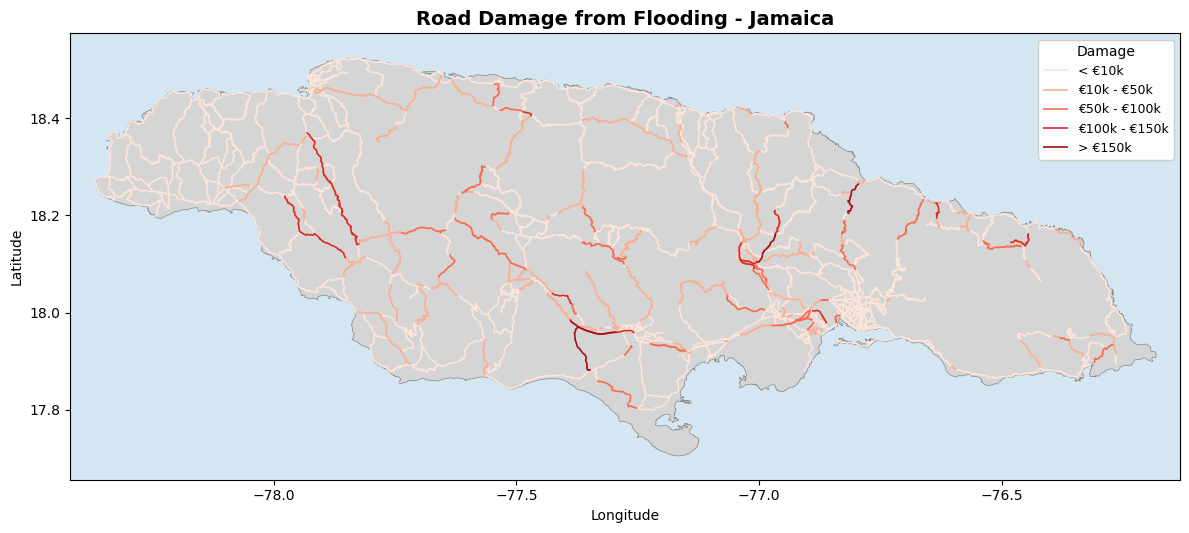

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))

# Set sea color (axes background)
ax.set_facecolor("#d4e6f1")  # Light blue for sea

# Read multipolygons layer - often contains land/admin boundaries
boundaries = gpd.read_file(exposure, layer="multipolygons")

# Look for admin boundary or large natural features
jamaica_outline = boundaries.loc[
    (boundaries.name == "Jamaica") & (boundaries["type"] == "multipolygon")
]

# Plot land (grey)
jamaica_outline.plot(ax=ax, color="#d5d5d5", edgecolor="#888888", linewidth=0.5)

# Define 5 bins for damage
damage_values = road_damages["damage"]
bins = [0, 10000, 50000, 100000, 150000, damage_values.max() + 1]
labels = ["< €10k", "€10k - €50k", "€50k - €100k", "€100k - €150k", "> €150k"]
colors = ["#fee5d9", "#fcae91", "#fb6a4a", "#de2d26", "#a50f15"]

# Assign bins
road_damages["damage_bin"] = pd.cut(
    damage_values, bins=bins, labels=labels, include_lowest=True
)

# Plot each bin separately for legend
for label, color in zip(labels, colors):
    subset = road_damages[road_damages["damage_bin"] == label]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, linewidth=1.2, label=label)

# Styling
ax.set_title("Road Damage from Flooding - Jamaica", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Damage", loc="upper right", framealpha=0.95, fontsize=9)
ax.set_aspect("equal")

# Set extent to Jamaica bounds with small buffer
bounds = jamaica_outline.total_bounds
buffer = 0.05
ax.set_xlim(bounds[0] - buffer, bounds[2] + buffer)
ax.set_ylim(bounds[1] - buffer, bounds[3] + buffer)

plt.tight_layout()
plt.show()